# Análisis de Sentimientos — Reseñas de Celulares en Amazon

**Objetivo:** Analizar el sentimiento de reseñas de celulares en Amazon utilizando VADER, enriquecido con vocabulario del dominio de telefonía. Comparar con calificaciones reales para evaluar la efectividad del método.

## Configuración Inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import string
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, cohen_kappa_score
)

# Descargar recursos de NLTK
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## Fase 1 — Exploración y Preprocesamiento

### 1.1 Carga y Exploración Inicial

In [2]:
# Cargar dataset
df = pd.read_csv('Amazon-Reviews-Essential.csv')
print(f'Total de reseñas: {len(df):,}')
print(f'Columnas: {list(df.columns)}')
print(f'\nPrimeras filas:')
df.head()

Total de reseñas: 413,802
Columnas: ['Rating', 'Reviews']

Primeras filas:


,Rating,Reviews
0,5.0,I feel so LUCKY to have found this used (phone...
1,4.0,"nice phone, nice up grade from my pantach revu..."
2,5.0,Very pleased
3,4.0,It works good but it goes slow sometimes but i...
4,4.0,Great phone to replace my lost phone. The only...


In [3]:
# Estadísticas descriptivas
print('=== Estadísticas del Dataset ===')
print(f'Total de reseñas: {len(df):,}')
print(f'\nDistribución de Ratings:')
print(df['Rating'].value_counts().sort_index())
print(f'\nValores nulos:')
print(df.isnull().sum())
print(f'\nReseñas vacías: {(df["Reviews"] == "").sum()}')
print(f'Longitud promedio de texto: {df["Reviews"].str.len().mean():.0f} caracteres')

=== Estadísticas del Dataset ===
Total de reseñas: 413,802

Distribución de Ratings:
Rating
1.0     72343
2.0     24728
3.0     31760
4.0     61389
5.0    223566
Name: count, dtype: int64

Valores nulos:
Rating     16
Reviews    86
dtype: int64

Reseñas vacías: 0
Longitud promedio de texto: 217 caracteres


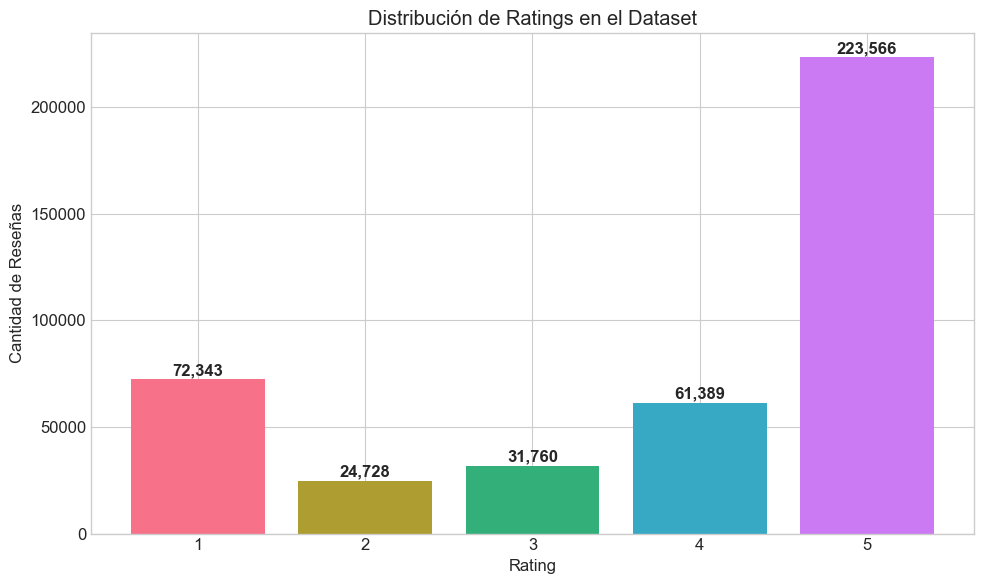

Gráfica guardada: 01_distribucion_ratings.png


In [4]:
# Histograma de distribución de ratings
fig, ax = plt.subplots(figsize=(10, 6))
rating_counts = df['Rating'].value_counts().sort_index()
bars = ax.bar(rating_counts.index, rating_counts.values, color=sns.color_palette('husl', 5))
ax.set_xlabel('Rating')
ax.set_ylabel('Cantidad de Reseñas')
ax.set_title('Distribución de Ratings en el Dataset')
ax.set_xticks([1, 2, 3, 4, 5])

for bar, count in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 500,
            f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('01_distribucion_ratings.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: 01_distribucion_ratings.png')

### 1.2 Limpieza del Texto

In [5]:
# Crear muestra estratificada para desarrollo rápido
SAMPLE_SIZE = 50000
if len(df) > SAMPLE_SIZE:
    df_sample = df.groupby('Rating', group_keys=False).apply(
        lambda x: x.sample(min(len(x), SAMPLE_SIZE // 5), random_state=42),
        include_groups=False
    ).reset_index(drop=True)
    # Restaurar columna Rating desde el índice original
    df_sample = df.loc[df_sample.index].copy()
    print(f'Muestra estratificada creada: {len(df_sample):,} reseñas')
else:
    df_sample = df.copy()
    print(f'Usando dataset completo: {len(df_sample):,} reseñas')

print(f'\nDistribución en muestra:')
print(df_sample['Rating'].value_counts().sort_index())

Muestra estratificada creada: 50,000 reseñas

Distribución en muestra:
Rating
1.0    10290
2.0     2686
3.0     3172
4.0     6110
5.0    27742
Name: count, dtype: int64


In [6]:
def limpiar_texto(texto):
    """Limpia el texto de una reseña."""
    if pd.isna(texto):
        return ''
    
    # Convertir a string y minúsculas
    texto = str(texto).lower()
    
    # Eliminar URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto)
    
    # Eliminar correos electrónicos
    texto = re.sub(r'\S+@\S+\.\S+', '', texto)
    
    # Eliminar caracteres especiales y números aislados
    # Conservar números que forman parte de modelos (ej: Galaxy S2)
    texto = re.sub(r'(?<![a-zA-Z])\d+(?![a-zA-Z])', '', texto)
    
    # Eliminar signos de puntuación
    texto = re.sub(r'[{}]'.format(re.escape(string.punctuation)), ' ', texto)
    
    # Eliminar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    return texto

# Aplicar limpieza
df_sample['Reviews_Limpio'] = df_sample['Reviews'].apply(limpiar_texto)

# Mostrar ejemplos
print('=== Ejemplos de Limpieza ===')
for i in range(3):
    print(f'\nOriginal: {df_sample.iloc[i]["Reviews"][:100]}...')
    print(f'Limpio: {df_sample.iloc[i]["Reviews_Limpio"][:100]}...')

=== Ejemplos de Limpieza ===

Original: I feel so LUCKY to have found this used (phone to us & not used hard at all), phone on line from som...
Limpio: i feel so lucky to have found this used phone to us not used hard at all phone on line from someone ...

Original: nice phone, nice up grade from my pantach revue. Very clean set up and easy set up. never had an and...
Limpio: nice phone nice up grade from my pantach revue very clean set up and easy set up never had an androi...

Original: Very pleased...
Limpio: very pleased...


In [7]:
# Eliminar stopwords y lematizar
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def procesar_texto(texto):
    """Elimina stopwords y aplica lematización."""
    if not texto:
        return ''
    
    tokens = word_tokenize(texto)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df_sample['Reviews_Procesado'] = df_sample['Reviews_Limpio'].apply(procesar_texto)

print('Ejemplo de procesamiento:')
print(f'Limpio: {df_sample.iloc[0]["Reviews_Limpio"][:100]}...')
print(f'Procesado: {df_sample.iloc[0]["Reviews_Procesado"][:100]}...')

Ejemplo de procesamiento:
Limpio: i feel so lucky to have found this used phone to us not used hard at all phone on line from someone ...
Procesado: feel lucky found used phone used hard phone line someone upgraded sold one son liked old one finally...


### 1.3 Definición de Etiquetas Ground Truth

In [8]:
def rating_a_sentimiento(rating):
    """Convierte rating numérico a categoría de sentimiento."""
    if rating <= 2:
        return 'Negativo'
    elif rating == 3:
        return 'Neutro'
    else:
        return 'Positivo'

df_sample['Sentimiento_Real'] = df_sample['Rating'].apply(rating_a_sentimiento)

print('Distribución de sentimientos (ground truth):')
print(df_sample['Sentimiento_Real'].value_counts())
print(f'\nPorcentajes:')
print(df_sample['Sentimiento_Real'].value_counts(normalize=True).round(4) * 100)

Distribución de sentimientos (ground truth):
Sentimiento_Real
Positivo    33852
Negativo    12976
Neutro       3172
Name: count, dtype: int64

Porcentajes:
Sentimiento_Real
Positivo    67.70
Negativo    25.95
Neutro       6.34
Name: proportion, dtype: float64


---
## Fase 2 — Análisis de Sentimiento con VADER

### 2.1 Análisis con VADER Base

In [9]:
# Análisis con VADER base (sin enriquecimiento)
sia_base = SentimentIntensityAnalyzer()

def analizar_sentimiento(texto, analyzer):
    """Analiza sentimiento usando VADER."""
    if not texto:
        return {'compound': 0, 'pos': 0, 'neg': 0, 'neu': 0}
    return analyzer.polarity_scores(texto)

# Aplicar análisis base
df_sample['Scores_Base'] = df_sample['Reviews_Limpio'].apply(
    lambda x: analizar_sentimiento(x, sia_base)
)
df_sample['Compound_Base'] = df_sample['Scores_Base'].apply(lambda x: x['compound'])

print('Estadísticas del compound score (VADER base):')
print(df_sample['Compound_Base'].describe())

Estadísticas del compound score (VADER base):
count    50000.000000
mean         0.344861
std          0.503494
min         -0.991800
25%          0.000000
50%          0.492700
75%          0.765000
max          0.999800
Name: Compound_Base, dtype: float64


### 2.2 Enriquecimiento del Léxico con Vocabulario del Dominio

In [10]:
# Diccionario de dominio de telefonía
DOMAIN_LEXICON = {
    'laggy': -2.5, 'lag': -2.0, 'overheating': -2.5, 'overheat': -2.0,
    'bloatware': -2.0, 'bricked': -3.5, 'unresponsive': -2.5, 'cracked': -2.5,
    'refurbished': -0.5, 'glitchy': -2.0, 'dead pixel': -2.5, 'battery drain': -2.5,
    'fast charging': 2.0, 'snappy': 2.0, 'crisp': 1.5, 'flagship': 1.5,
    'waterproof': 1.5, 'upgrade': 1.5, 'downgrade': -2.0, 'scratched': -2.0,
    'durable': 1.5, 'flimsy': -2.0, 'overpriced': -2.0, 'bargain': 2.0,
    'scam': -3.5, 'knockoff': -2.5, 'defective': -3.0, 'freezing': -2.0,
    'smooth': 1.5, 'responsive': 1.5
}

print(f'Términos en el léxico de dominio: {len(DOMAIN_LEXICON)}')
print(f'\nTérminos negativos: {sum(1 for v in DOMAIN_LEXICON.values() if v < 0)}')
print(f'Términos positivos: {sum(1 for v in DOMAIN_LEXICON.values() if v > 0)}')

Términos en el léxico de dominio: 30

Términos negativos: 20
Términos positivos: 10


In [11]:
# Crear VADER con léxico enriquecido
sia_enriched = SentimentIntensityAnalyzer()
sia_enriched.lexicon.update(DOMAIN_LEXICON)

print('Léxico de dominio agregado a VADER.')
print(f'Tamaño del léxico: {len(sia_enriched.lexicon)} palabras')

Léxico de dominio agregado a VADER.
Tamaño del léxico: 7525 palabras


In [12]:
# Aplicar análisis con léxico enriquecido
df_sample['Scores_Enriched'] = df_sample['Reviews_Limpio'].apply(
    lambda x: analizar_sentimiento(x, sia_enriched)
)
df_sample['Compound_Enriched'] = df_sample['Scores_Enriched'].apply(lambda x: x['compound'])

print('Estadísticas del compound score (VADER enriquecido):')
print(df_sample['Compound_Enriched'].describe())

Estadísticas del compound score (VADER enriquecido):
count    50000.000000
mean         0.338897
std          0.511276
min         -0.990100
25%          0.000000
50%          0.492700
75%          0.765000
max          0.999800
Name: Compound_Enriched, dtype: float64


### 2.3 Clasificación de Sentimientos

In [13]:
def clasificar_sentimiento(compound):
    """Clasifica sentimiento según compound score."""
    if compound >= 0.05:
        return 'Positivo'
    elif compound <= -0.05:
        return 'Negativo'
    else:
        return 'Neutro'

# Clasificar con ambos modelos
df_sample['Sentimiento_Base'] = df_sample['Compound_Base'].apply(clasificar_sentimiento)
df_sample['Sentimiento_Enriched'] = df_sample['Compound_Enriched'].apply(clasificar_sentimiento)

print('=== Distribución de Predicciones ===')
print(f'\nVADER Base:')
print(df_sample['Sentimiento_Base'].value_counts())
print(f'\nVADER Enriquecido:')
print(df_sample['Sentimiento_Enriched'].value_counts())

=== Distribución de Predicciones ===

VADER Base:
Sentimiento_Base
Positivo    33888
Negativo     9405
Neutro       6707
Name: count, dtype: int64

VADER Enriquecido:
Sentimiento_Enriched
Positivo    33797
Negativo     9704
Neutro       6499
Name: count, dtype: int64


---
## Fase 3 — Evaluación del Modelo

### 3.1 Métricas de Evaluación

In [14]:
def evaluar_modelo(y_true, y_pred, nombre):
    """Evalúa un modelo y retorna las métricas."""
    print(f'\n=== Evaluación: {nombre} ===')
    
    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    
    # Classification Report
    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred))
    
    # Cohen's Kappa
    kappa = cohen_kappa_score(y_true, y_pred)
    print(f'Cohen\'s Kappa: {kappa:.4f}')
    
    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred, labels=['Negativo', 'Neutro', 'Positivo'])
    
    return {'accuracy': acc, 'kappa': kappa, 'cm': cm}

# Evaluar VADER Base
metrics_base = evaluar_modelo(
    df_sample['Sentimiento_Real'],
    df_sample['Sentimiento_Base'],
    'VADER Base'
)


=== Evaluación: VADER Base ===
Accuracy: 0.7243 (72.43%)

Classification Report:


              precision    recall  f1-score   support

    Negativo       0.72      0.52      0.60     12976
      Neutro       0.08      0.17      0.11      3172
    Positivo       0.85      0.85      0.85     33852

    accuracy                           0.72     50000
   macro avg       0.55      0.52      0.52     50000
weighted avg       0.77      0.72      0.74     50000

Cohen's Kappa: 0.4302


In [15]:
# Evaluar VADER Enriquecido
metrics_enriched = evaluar_modelo(
    df_sample['Sentimiento_Real'],
    df_sample['Sentimiento_Enriched'],
    'VADER Enriquecido'
)


=== Evaluación: VADER Enriquecido ===
Accuracy: 0.7289 (72.89%)

Classification Report:


              precision    recall  f1-score   support

    Negativo       0.72      0.54      0.62     12976
      Neutro       0.08      0.17      0.11      3172
    Positivo       0.86      0.85      0.86     33852

    accuracy                           0.73     50000
   macro avg       0.55      0.52      0.53     50000
weighted avg       0.77      0.73      0.75     50000

Cohen's Kappa: 0.4395


### 3.2 Impacto del Enriquecimiento

In [16]:
# Impacto del enriquecimiento
print('=== IMPACTO DEL ENRIQUECIMIENTO DEL LÉXICO ===')
print(f'\nAccuracy Base:        {metrics_base["accuracy"]:.4f}')
print(f'Accuracy Enriquecido: {metrics_enriched["accuracy"]:.4f}')
print(f'Delta:                {metrics_enriched["accuracy"] - metrics_base["accuracy"]:+.4f}')
print(f'\nKappa Base:           {metrics_base["kappa"]:.4f}')
print(f'Kappa Enriquecido:    {metrics_enriched["kappa"]:.4f}')
print(f'Delta:                {metrics_enriched["kappa"] - metrics_base["kappa"]:+.4f}')

# F1-Score por clase (usando average=None para obtener métricas por clase)
clases = ['Negativo', 'Neutro', 'Positivo']
precision_base, recall_base, f1_base, _ = precision_recall_fscore_support(
    df_sample['Sentimiento_Real'], df_sample['Sentimiento_Base'],
    labels=clases, average=None, zero_division=0
)
precision_enr, recall_enr, f1_enr, _ = precision_recall_fscore_support(
    df_sample['Sentimiento_Real'], df_sample['Sentimiento_Enriched'],
    labels=clases, average=None, zero_division=0
)
print(f'\n=== F1-Score por Clase ===')
for i, clase in enumerate(clases):
    print(f'{clase}: Base={f1_base[i]:.4f}, Enriquecido={f1_enr[i]:.4f}, Delta={f1_enr[i]-f1_base[i]:+.4f}')

=== IMPACTO DEL ENRIQUECIMIENTO DEL LÉXICO ===

Accuracy Base:        0.7243
Accuracy Enriquecido: 0.7289
Delta:                +0.0045

Kappa Base:           0.4302
Kappa Enriquecido:    0.4395
Delta:                +0.0093



=== F1-Score por Clase ===
Negativo: Base=0.6036, Enriquecido=0.6153, Delta=+0.0117
Neutro: Base=0.1093, Enriquecido=0.1104, Delta=+0.0011
Positivo: Base=0.8539, Enriquecido=0.8554, Delta=+0.0014


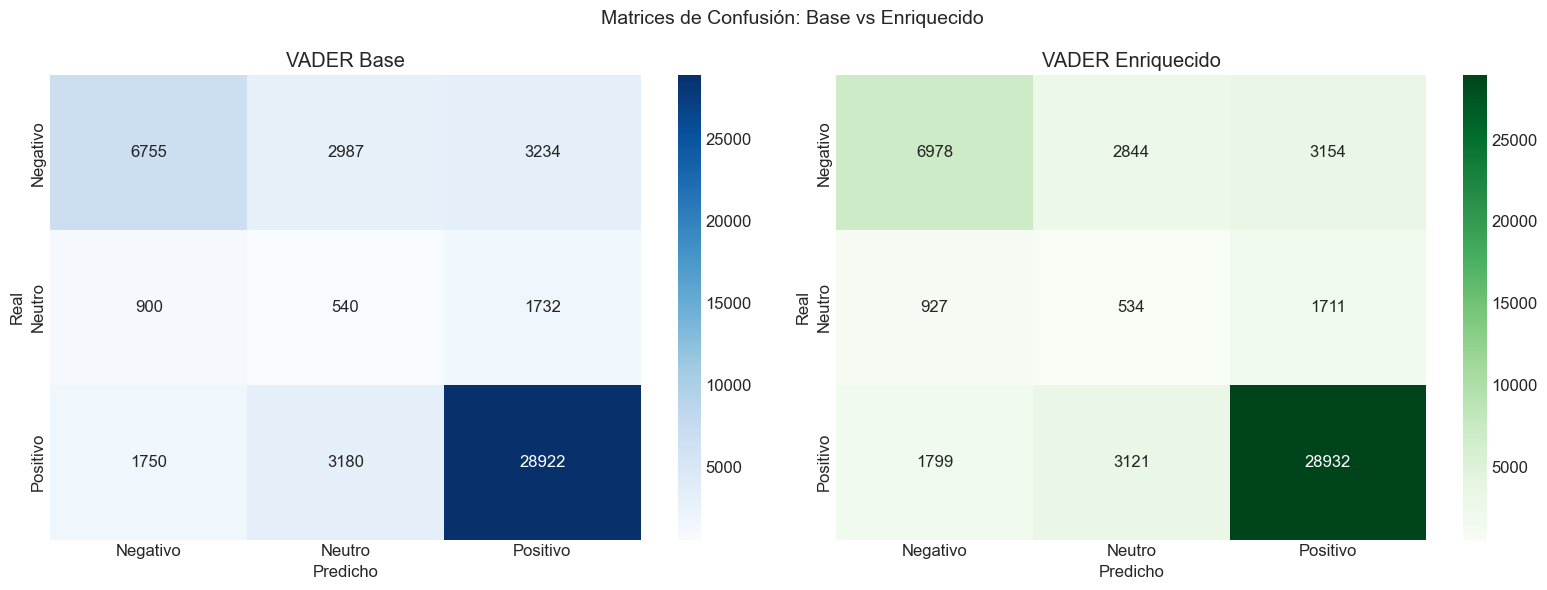

Gráfica guardada: 02_matrices_confusion.png


In [17]:
# Matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels = ['Negativo', 'Neutro', 'Positivo']

sns.heatmap(metrics_base['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('VADER Base')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

sns.heatmap(metrics_enriched['cm'], annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('VADER Enriquecido')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.suptitle('Matrices de Confusión: Base vs Enriquecido', fontsize=14)
plt.tight_layout()
plt.savefig('02_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: 02_matrices_confusion.png')

---
## Fase 4 — Hallazgos y Análisis Profundo

### 4.1 Análisis de Errores

In [18]:
# Identificar errores del modelo enriquecido
df_errores = df_sample[df_sample['Sentimiento_Real'] != df_sample['Sentimiento_Enriched']].copy()
print(f'Total de errores: {len(df_errores):,} ({len(df_errores)/len(df_sample)*100:.2f}%)')

# Falsos positivos: Rating bajo clasificado como positivo
falsos_positivos = df_errores[
    (df_errores['Sentimiento_Real'] == 'Negativo') & 
    (df_errores['Sentimiento_Enriched'] == 'Positivo')
]
print(f'\nFalsos Positivos: {len(falsos_positivos):,}')

# Falsos negativos: Rating alto clasificado como negativo
falsos_negativos = df_errores[
    (df_errores['Sentimiento_Real'] == 'Positivo') & 
    (df_errores['Sentimiento_Enriched'] == 'Negativo')
]
print(f'Falsos Negativos: {len(falsos_negativos):,}')

Total de errores: 13,556 (27.11%)

Falsos Positivos: 3,154
Falsos Negativos: 1,799


In [19]:
print('=== EJEMPLOS DE FALSOS POSITIVOS ===')
print('(Reseñas con rating bajo clasificadas como positivas)\n')

for idx, row in falsos_positivos.head(5).iterrows():
    print(f'Rating: {row["Rating"]} | Compound: {row["Compound_Enriched"]:.3f}')
    print(f'Texto: {row["Reviews"][:150]}...')
    print('-' * 80)

=== EJEMPLOS DE FALSOS POSITIVOS ===
(Reseñas con rating bajo clasificadas como positivas)

Rating: 1.0 | Compound: 0.686
Texto: I'm really disappointed about my phone and service. The phone went out on me over a week ago. Instead of handling it when issue first surfaced. I've b...
--------------------------------------------------------------------------------
Rating: 1.0 | Compound: 0.850
Texto: I purchased this phone in December as a christmas present to my son. I called sprint to activate the phone only to find out the ESN wasn't clear. I wa...
--------------------------------------------------------------------------------
Rating: 1.0 | Compound: 0.654
Texto: Just... not good. The phone has great screen resolution, storage is low, you need an SD card to do anything. May have a clear ESN but don't expect to ...
--------------------------------------------------------------------------------
Rating: 2.0 | Compound: 0.735
Texto: I like these phone I bought it for my mom and she loves

In [20]:
print('=== EJEMPLOS DE FALSOS NEGATIVOS ===')
print('(Reseñas con rating alto clasificadas como negativas)\n')

for idx, row in falsos_negativos.head(5).iterrows():
    print(f'Rating: {row["Rating"]} | Compound: {row["Compound_Enriched"]:.3f}')
    print(f'Texto: {row["Reviews"][:150]}...')
    print('-' * 80)

=== EJEMPLOS DE FALSOS NEGATIVOS ===
(Reseñas con rating alto clasificadas como negativas)

Rating: 4.0 | Compound: -0.296
Texto: The battery was old & had been over used because it barely holds a charge. Otherwise, no issues with the phone itself....
--------------------------------------------------------------------------------
Rating: 5.0 | Compound: -0.402
Texto: Phone is working on, I was planning to use it for whatsapp anyway. The oh problem, I can't change the idiom...
--------------------------------------------------------------------------------
Rating: 4.0 | Compound: -0.340
Texto: I have no problem taking the phone to straight talk.The phone came in about 3weeks. The only thing I didn't like was the camera its horrible when tryi...
--------------------------------------------------------------------------------
Rating: 4.0 | Compound: -0.542
Texto: Its great for the price but I hate how you can not change the lock screen to what you wantAnd just has the default wallpapers 

### 4.2 Análisis de Palabras Clave

In [21]:
def obtener_palabras_frecuentes(textos, n=20):
    """Obtiene las palabras más frecuentes de una serie de textos."""
    todas_palabras = ' '.join(textos.dropna()).split()
    return Counter(todas_palabras).most_common(n)

# Palabras por sentimiento
for sentimiento in ['Positivo', 'Negativo', 'Neutro']:
    mask = df_sample['Sentimiento_Real'] == sentimiento
    palabras = obtener_palabras_frecuentes(df_sample[mask]['Reviews_Procesado'])
    print(f'\n=== Top 10 palabras - {sentimiento} ===')
    for palabra, count in palabras[:10]:
        print(f'  {palabra}: {count:,}')


=== Top 10 palabras - Positivo ===
  phone: 23,724
  great: 11,682
  work: 7,250
  good: 7,160
  new: 6,148
  iphone: 5,997
  love: 4,920
  like: 4,193
  condition: 3,671
  came: 3,331

=== Top 10 palabras - Negativo ===
  phone: 15,932
  work: 3,373
  iphone: 2,627
  new: 2,397
  screen: 2,206
  battery: 2,154
  apple: 1,970
  would: 1,913
  get: 1,907
  one: 1,773

=== Top 10 palabras - Neutro ===
  phone: 3,405
  work: 1,000
  good: 807
  screen: 607
  new: 602
  iphone: 565
  great: 523
  battery: 513
  like: 511
  one: 471


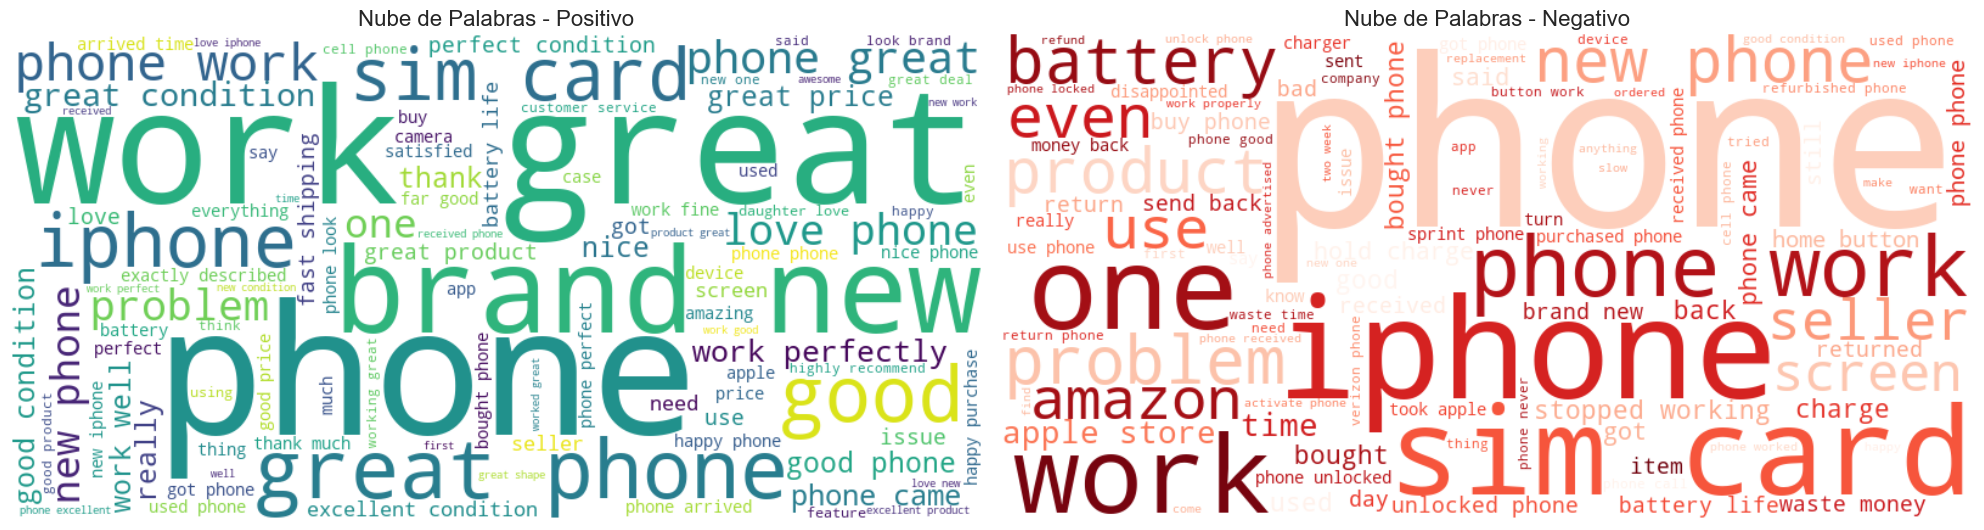

Gráfica guardada: 03_nubes_palabras.png


In [22]:
# Nubes de palabras
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for idx, sentimiento in enumerate(['Positivo', 'Negativo']):
    mask = df_sample['Sentimiento_Real'] == sentimiento
    texto = ' '.join(df_sample[mask]['Reviews_Procesado'].dropna())
    
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        max_words=100,
        colormap='viridis' if sentimiento == 'Positivo' else 'Reds'
    ).generate(texto)
    
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'Nube de Palabras - {sentimiento}', fontsize=16)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('03_nubes_palabras.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: 03_nubes_palabras.png')

In [23]:
# Bigramas más comunes
from nltk.util import ngrams

def obtener_bigramas(textos, n=20):
    """Obtiene los bigramas más frecuentes."""
    todos_bigramas = []
    for texto in textos.dropna():
        tokens = texto.split()
        todos_bigramas.extend([' '.join(bg) for bg in ngrams(tokens, 2)])
    return Counter(todos_bigramas).most_common(n)

print('=== Top 10 Bigramas por Sentimiento ===')
for sentimiento in ['Positivo', 'Negativo']:
    mask = df_sample['Sentimiento_Real'] == sentimiento
    bigramas = obtener_bigramas(df_sample[mask]['Reviews_Procesado'], 10)
    print(f'\n{sentimiento}:')
    for bigrama, count in bigramas:
        print(f'  {bigrama}: {count:,}')

=== Top 10 Bigramas por Sentimiento ===



Positivo:
  work great: 2,107
  brand new: 1,986
  great phone: 1,806
  sim card: 1,508
  phone work: 1,360
  like new: 1,123
  phone great: 1,068
  love phone: 961
  new phone: 875
  great condition: 847



Negativo:
  sim card: 839
  phone work: 564
  new phone: 483
  apple store: 415
  stopped working: 397
  bought phone: 369
  hold charge: 317
  phone would: 305
  phone came: 299
  home button: 269


### 4.3 Relación Longitud del Texto vs Sentimiento

C:\Users\RyzenCooler\AppData\Local\Temp\ipykernel_15172\1357115912.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample, x='Sentimiento_Real', y='Longitud',
C:\Users\RyzenCooler\AppData\Local\Temp\ipykernel_15172\1357115912.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_sample, x='Sentimiento_Real', y='Longitud',


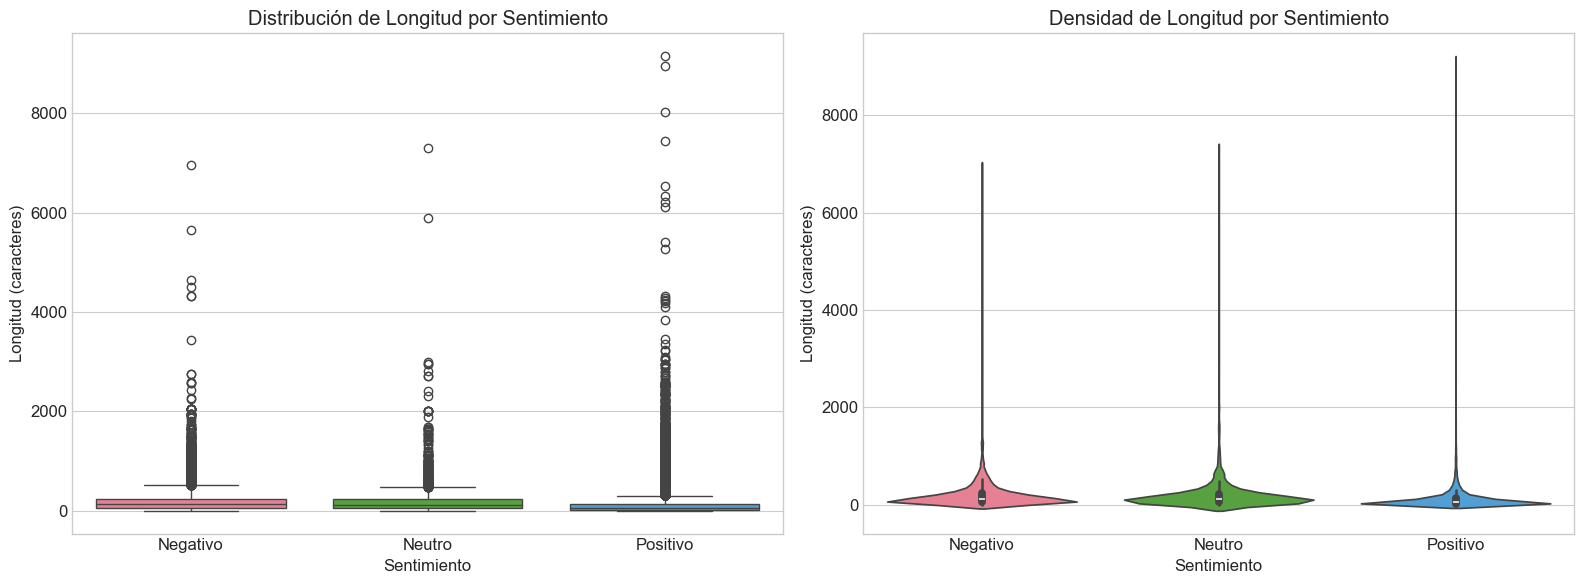


=== Estadísticas de Longitud por Sentimiento ===
                    count        mean         std  min   25%    50%     75%  \
Sentimiento_Real                                                              
Negativo          12971.0  203.131447  256.882733  2.0  62.0  130.0  246.00   
Neutro             3172.0  199.356557  307.796990  2.0  64.0  122.0  232.25   
Positivo          33844.0  127.458781  257.419896  1.0  21.0   58.0  136.00   

                     max  
Sentimiento_Real          
Negativo          6960.0  
Neutro            7291.0  
Positivo          9150.0  


In [24]:
# Longitud de texto por sentimiento
df_sample['Longitud'] = df_sample['Reviews'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sentiment_order = ['Negativo', 'Neutro', 'Positivo']
sns.boxplot(data=df_sample, x='Sentimiento_Real', y='Longitud', 
            order=sentiment_order, ax=axes[0], palette='husl')
axes[0].set_title('Distribución de Longitud por Sentimiento')
axes[0].set_xlabel('Sentimiento')
axes[0].set_ylabel('Longitud (caracteres)')

# Violin plot
sns.violinplot(data=df_sample, x='Sentimiento_Real', y='Longitud',
               order=sentiment_order, ax=axes[1], palette='husl')
axes[1].set_title('Densidad de Longitud por Sentimiento')
axes[1].set_xlabel('Sentimiento')
axes[1].set_ylabel('Longitud (caracteres)')

plt.tight_layout()
plt.savefig('04_longitud_sentimiento.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas
print('\n=== Estadísticas de Longitud por Sentimiento ===')
print(df_sample.groupby('Sentimiento_Real')['Longitud'].describe())

---
## Fase 5 — Visualizaciones Adicionales

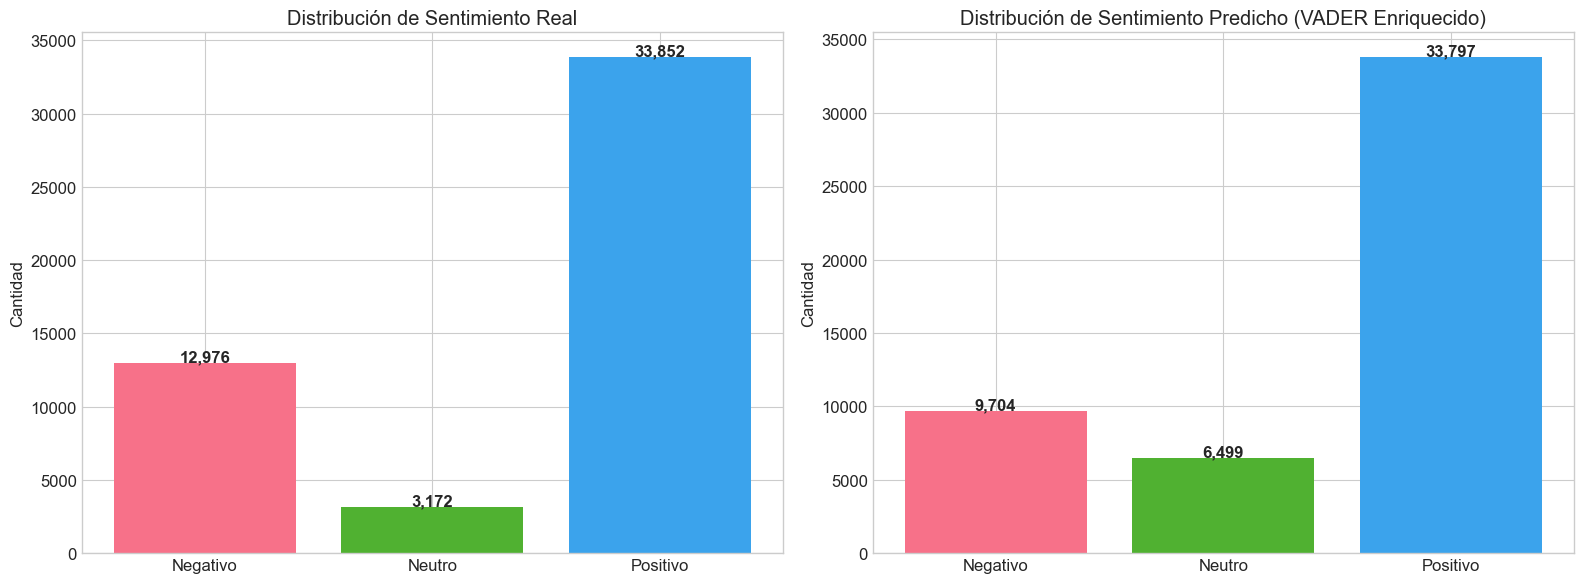

Gráfica guardada: 05_real_vs_predicho.png


In [25]:
# Gráfico de barras: Sentimiento real vs predicho
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución real
real_counts = df_sample['Sentimiento_Real'].value_counts().reindex(sentiment_order)
axes[0].bar(real_counts.index, real_counts.values, color=sns.color_palette('husl', 3))
axes[0].set_title('Distribución de Sentimiento Real')
axes[0].set_ylabel('Cantidad')
for i, (val, count) in enumerate(zip(real_counts.index, real_counts.values)):
    axes[0].text(i, count + 100, f'{count:,}', ha='center', fontweight='bold')

# Distribución predicha
pred_counts = df_sample['Sentimiento_Enriched'].value_counts().reindex(sentiment_order)
axes[1].bar(pred_counts.index, pred_counts.values, color=sns.color_palette('husl', 3))
axes[1].set_title('Distribución de Sentimiento Predicho (VADER Enriquecido)')
axes[1].set_ylabel('Cantidad')
for i, (val, count) in enumerate(zip(pred_counts.index, pred_counts.values)):
    axes[1].text(i, count + 100, f'{count:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('05_real_vs_predicho.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: 05_real_vs_predicho.png')

C:\Users\RyzenCooler\AppData\Local\Temp\ipykernel_15172\1572855750.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample, x='Rating', y='Compound_Enriched', ax=ax, palette='husl')


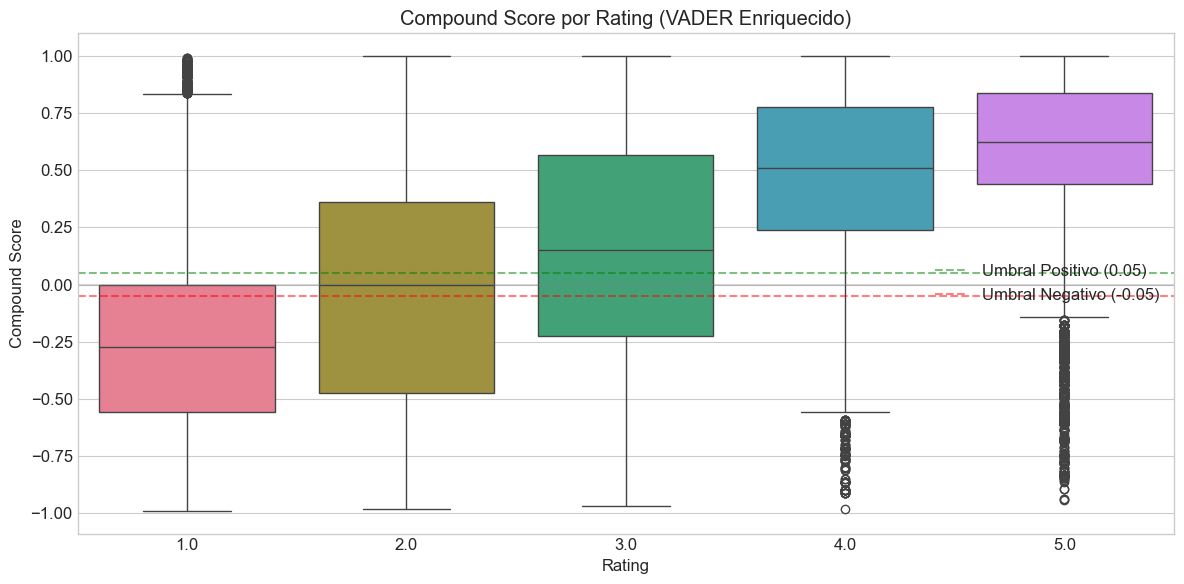

Gráfica guardada: 06_compound_por_rating.png


In [26]:
# Boxplot de compound score por rating
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=df_sample, x='Rating', y='Compound_Enriched', ax=ax, palette='husl')
ax.axhline(y=0.05, color='green', linestyle='--', alpha=0.5, label='Umbral Positivo (0.05)')
ax.axhline(y=-0.05, color='red', linestyle='--', alpha=0.5, label='Umbral Negativo (-0.05)')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

ax.set_title('Compound Score por Rating (VADER Enriquecido)')
ax.set_xlabel('Rating')
ax.set_ylabel('Compound Score')
ax.legend()

plt.tight_layout()
plt.savefig('06_compound_por_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: 06_compound_por_rating.png')

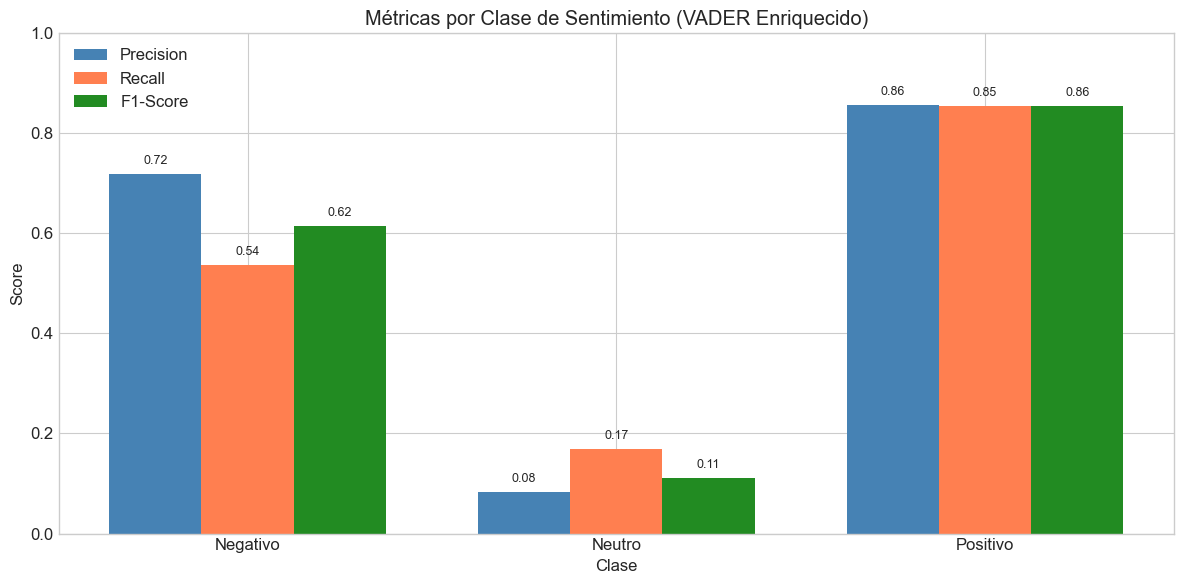

Gráfica guardada: 07_metricas_por_clase.png


In [27]:
# Métricas por clase
report = classification_report(
    df_sample['Sentimiento_Real'],
    df_sample['Sentimiento_Enriched'],
    output_dict=True
)

fig, ax = plt.subplots(figsize=(12, 6))

clases = ['Negativo', 'Neutro', 'Positivo']
x = np.arange(len(clases))
width = 0.25

precision = [report[c]['precision'] for c in clases]
recall = [report[c]['recall'] for c in clases]
f1 = [report[c]['f1-score'] for c in clases]

ax.bar(x - width, precision, width, label='Precision', color='steelblue')
ax.bar(x, recall, width, label='Recall', color='coral')
ax.bar(x + width, f1, width, label='F1-Score', color='forestgreen')

ax.set_xlabel('Clase')
ax.set_ylabel('Score')
ax.set_title('Métricas por Clase de Sentimiento (VADER Enriquecido)')
ax.set_xticks(x)
ax.set_xticklabels(clases)
ax.legend()
ax.set_ylim(0, 1)

# Agregar valores
for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    ax.text(i - width, p + 0.02, f'{p:.2f}', ha='center', fontsize=9)
    ax.text(i, r + 0.02, f'{r:.2f}', ha='center', fontsize=9)
    ax.text(i + width, f + 0.02, f'{f:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('07_metricas_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: 07_metricas_por_clase.png')

---
## Fase 6 — Conclusiones

In [28]:
print('='*70)
print('CONCLUSIONES DEL ANÁLISIS DE SENTIMIENTOS')
print('='*70)

print(f'''\n1. EFECTIVIDAD DEL LÉXICO VADER
   - Accuracy VADER Base: {metrics_base["accuracy"]:.4f} ({metrics_base["accuracy"]*100:.2f}%)
   - Accuracy VADER Enriquecido: {metrics_enriched["accuracy"]:.4f} ({metrics_enriched["accuracy"]*100:.2f}%)
   - Cohen's Kappa Base: {metrics_base["kappa"]:.4f}
   - Cohen's Kappa Enriquecido: {metrics_enriched["kappa"]:.4f}

2. IMPACTO DEL ENRIQUECIMIENTO
   - Delta Accuracy: {metrics_enriched["accuracy"] - metrics_base["accuracy"]:+.4f}
   - El enriquecimiento del léxico con vocabulario de dominio {"mejoró" if metrics_enriched["accuracy"] > metrics_base["accuracy"] else "no mejoró significativamente"} la clasificación.

3. LIMITACIONES IDENTIFICADAS
   - Sarcasmo: VADER no detecta ironía como "Great... it broke in 2 days"
   - Negaciones complejas: "not bad" puede clasificarse erróneamente
   - Reseñas ambiguas: Textos cortos o genéricos
   - Total de errores: {len(df_errores):,} ({len(df_errores)/len(df_sample)*100:.2f}%)

4. HALLAZGOS DEL DOMINIO
   - Los consumidores valoran: batería, pantalla, relación precio-calidad
   - Principales quejas: defectos de hardware, productos usados, estafas
   - Las reseñas negativas tienden a ser más largas y detalladas

5. RECOMENDACIONES
   - Considerar modelos de ML (BERT, RoBERTa) para mejor precisión
   - Ampliar el léxico de dominio con más términos técnicos
   - Implementar detección de sarcasmo básica
   - Analizar n-gramas más largos para capturar contexto''')

print('\n' + '='*70)
print('ANÁLISIS COMPLETADO')
print('='*70)

CONCLUSIONES DEL ANÁLISIS DE SENTIMIENTOS

1. EFECTIVIDAD DEL LÉXICO VADER
   - Accuracy VADER Base: 0.7243 (72.43%)
   - Accuracy VADER Enriquecido: 0.7289 (72.89%)
   - Cohen's Kappa Base: 0.4302
   - Cohen's Kappa Enriquecido: 0.4395

2. IMPACTO DEL ENRIQUECIMIENTO
   - Delta Accuracy: +0.0045
   - El enriquecimiento del léxico con vocabulario de dominio mejoró la clasificación.

3. LIMITACIONES IDENTIFICADAS
   - Sarcasmo: VADER no detecta ironía como "Great... it broke in 2 days"
   - Negaciones complejas: "not bad" puede clasificarse erróneamente
   - Reseñas ambiguas: Textos cortos o genéricos
   - Total de errores: 13,556 (27.11%)

4. HALLAZGOS DEL DOMINIO
   - Los consumidores valoran: batería, pantalla, relación precio-calidad
   - Principales quejas: defectos de hardware, productos usados, estafas
   - Las reseñas negativas tienden a ser más largas y detalladas

5. RECOMENDACIONES
   - Considerar modelos de ML (BERT, RoBERTa) para mejor precisión
   - Ampliar el léxico de do

In [29]:
# Exportar resultados
df_sample.to_csv('resultados_analisis_sentimientos.csv', index=False)
print('Resultados exportados a: resultados_analisis_sentimientos.csv')

# Resumen de archivos generados
print('\n=== Archivos Generados ===')
print('1. 01_distribucion_ratings.png')
print('2. 02_matrices_confusion.png')
print('3. 03_nubes_palabras.png')
print('4. 04_longitud_sentimiento.png')
print('5. 05_real_vs_predicho.png')
print('6. 06_compound_por_rating.png')
print('7. 07_metricas_por_clase.png')
print('8. resultados_analisis_sentimientos.csv')

Resultados exportados a: resultados_analisis_sentimientos.csv

=== Archivos Generados ===
1. 01_distribucion_ratings.png
2. 02_matrices_confusion.png
3. 03_nubes_palabras.png
4. 04_longitud_sentimiento.png
5. 05_real_vs_predicho.png
6. 06_compound_por_rating.png
7. 07_metricas_por_clase.png
8. resultados_analisis_sentimientos.csv
